# Informe Teórico Práctico 1 – Limpieza, EDA y Transformación
**SI3015 – Fundamentos de Aprendizaje Automático**  
Dataset: Movies (IMDB-style)

## 0. Importación de librerías

In [1]:
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline


## 1. Carga del dataset e inspección rápida
Se carga el dataset de películas (`movies.csv`) y se realizan comandos básicos de inspección.

In [2]:
df_raw = pd.read_csv('movies.csv')

print("Forma del dataset:", df_raw.shape)
print()
print("Primeras filas:")
df_raw.head()


Forma del dataset: (9999, 9)

Primeras filas:


,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1000,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0000,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0000,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0000,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2000,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0000,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2000,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0000,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


In [3]:
print("Tipos de datos:")
print(df_raw.dtypes)
print()
print("Valores nulos por columna:")
print(df_raw.isnull().sum())
print()
print("Porcentaje de nulos:")
print((df_raw.isnull().sum() / len(df_raw) * 100).round(2))


Tipos de datos:
MOVIES          str
YEAR            str
GENRE           str
RATING      float64
ONE-LINE        str
STARS           str
VOTES           str
RunTime     float64
Gross           str
dtype: object

Valores nulos por columna:
MOVIES         0
YEAR         644
GENRE         80
RATING      1820
ONE-LINE       0
STARS          0
VOTES       1820
RunTime     2958
Gross       9539
dtype: int64

Porcentaje de nulos:
MOVIES      0.0000
YEAR        6.4400
GENRE       0.8000
RATING     18.2000
ONE-LINE    0.0000
STARS       0.0000
VOTES      18.2000
RunTime    29.5800
Gross      95.4000
dtype: float64


In [4]:
print("Estadísticas descriptivas básicas:")
df_raw.describe(include='all')


Estadísticas descriptivas básicas:


,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
count,9999,9355,9919,8179.0000,9999,9999,8179,7041.0000,460
unique,6817,438,510,NaN,8688,7877,4129,NaN,332
top,Bleach: Burîchi,(2020– ),\nComedy,NaN,\nAdd a Plot\n,\n,7,NaN,$0.01M
freq,65,892,852,NaN,1265,456,35,NaN,22
mean,NaN,NaN,NaN,6.9212,NaN,NaN,NaN,68.6885,NaN
std,NaN,NaN,NaN,1.2202,NaN,NaN,NaN,47.2581,NaN
min,NaN,NaN,NaN,1.1000,NaN,NaN,NaN,1.0000,NaN
25%,NaN,NaN,NaN,6.2000,NaN,NaN,NaN,36.0000,NaN
50%,NaN,NaN,NaN,7.1000,NaN,NaN,NaN,60.0000,NaN
75%,NaN,NaN,NaN,7.8000,NaN,NaN,NaN,95.0000,NaN


## 2. Limpieza del dataset
### 2.1 Corrección de columnas (errores de formato)
Las columnas presentan los siguientes problemas detectados en la inspección:
- **YEAR**: contiene paréntesis, guiones y espacios (e.g. `(2021)`, `(2010–2022)`, `(2021– )`).
- **GENRE**: tiene `\n` al inicio y espacios en blanco al final.
- **ONE-LINE**: tiene `\n` al inicio.
- **STARS**: mezcla director y actores con caracteres `\n` y espacios.
- **VOTES**: es cadena de texto con comas (e.g. `21,062`).
- **Gross**: es cadena con símbolo `$` y sufijo `M` (e.g. `$75.47M`).

In [5]:
df = df_raw.copy()

# ── YEAR: extraer primer año de 4 dígitos ──────────────────────────────────────
def extract_year(val):
    if pd.isna(val):
        return np.nan
    nums = re.findall(r'\d{4}', str(val))
    return int(nums[0]) if nums else np.nan

df['YEAR'] = df['YEAR'].apply(extract_year)

# ── GENRE: eliminar \n y espacios extra ─────────────────────────────────────
df['GENRE'] = df['GENRE'].str.replace('\n', '', regex=False).str.strip()

# ── ONE-LINE: eliminar \n y espacios extra ──────────────────────────────────
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\n', ' ', regex=False).str.strip()

# ── STARS: extraer director y lista de actores ───────────────────────────────
def extract_director(val):
    if pd.isna(val):
        return np.nan
    m = re.search(r'Director:\s*(.+?)\s*(\||Stars:|$)', str(val), re.DOTALL)
    if m:
        return m.group(1).strip().replace('\n', '').strip()
    return np.nan

def extract_stars(val):
    if pd.isna(val):
        return np.nan
    m = re.search(r'Stars:\s*(.+)', str(val), re.DOTALL)
    if m:
        stars = m.group(1).replace('\n', '').strip()
        stars = re.sub(r'\s+', ' ', stars).strip().rstrip(',')
        return stars
    return np.nan

df['DIRECTOR'] = df['STARS'].apply(extract_director)
df['STARS']    = df['STARS'].apply(extract_stars)

# ── VOTES: cadena con comas → numérico ────────────────────────────────────────
df['VOTES'] = pd.to_numeric(df['VOTES'].astype(str).str.replace(',', '', regex=False), errors='coerce')

# ── Gross: $XX.XXM → numérico (millones USD) ──────────────────────────────────
df['Gross'] = pd.to_numeric(
    df['Gross'].astype(str).str.replace(r'[\$M]', '', regex=True),
    errors='coerce'
)

# ── RunTime: asegurar tipo numérico ──────────────────────────────────────────
df['RunTime'] = pd.to_numeric(df['RunTime'], errors='coerce')

# ── RATING: asegurar tipo numérico ───────────────────────────────────────────
df['RATING'] = pd.to_numeric(df['RATING'], errors='coerce')

print("Tipos de datos tras corrección de columnas:")
print(df.dtypes)
print()
print("Primeras filas corregidas:")
df.head(3)


Tipos de datos tras corrección de columnas:


MOVIES          str
YEAR        float64
GENRE           str
RATING      float64
ONE-LINE        str
STARS           str
VOTES       float64
RunTime     float64
Gross       float64
DIRECTOR        str
dtype: object

Primeras filas corregidas:


,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross,DIRECTOR
0,Blood Red Sky,2021.0000,"Action, Horror, Thriller",6.1000,A woman with a mysterious illness is forced in...,"Peri Baumeister, Carl Anton Koch, Alexander Sc...",21062.0000,121.0000,NaN,Peter Thorwarth
1,Masters of the Universe: Revelation,2021.0000,"Animation, Action, Adventure",5.0000,The war for Eternia begins again in what may b...,"Chris Wood, Sarah Michelle Gellar, Lena Headey...",17870.0000,25.0000,NaN,NaN
2,The Walking Dead,2010.0000,"Drama, Horror, Thriller",8.2000,Sheriff Deputy Rick Grimes wakes up from a com...,"Andrew Lincoln, Norman Reedus, Melissa McBride...",885805.0000,44.0000,NaN,NaN


### 2.2 Manejo de valores faltantes (NaNs)

In [6]:
print("Valores nulos tras corrección:")
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nulos': null_counts, '% Nulos': null_pct})
print(null_df[null_df['Nulos'] > 0])


Valores nulos tras corrección:
          Nulos  % Nulos
YEAR        748   7.4800
GENRE        80   0.8000
RATING     1820  18.2000
STARS      1384  13.8400
VOTES      1820  18.2000
RunTime    2958  29.5800
Gross      9539  95.4000
DIRECTOR   4643  46.4300


In [7]:
# RATING y VOTES: filas con ambas nulas no aportan información de calidad → eliminar
before = len(df)
df = df.dropna(subset=['RATING', 'VOTES'])
print(f"Filas eliminadas por RATING y VOTES nulos: {before - len(df)}")

# YEAR: imputar con la mediana (año más frecuente)
year_median = df['YEAR'].median()
df['YEAR'] = df['YEAR'].fillna(year_median)
print(f"YEAR nulos imputados con mediana: {year_median}")

# GENRE: imputar con 'Unknown'
df['GENRE'] = df['GENRE'].fillna('Unknown')

# RunTime: imputar con la mediana
runtime_median = df['RunTime'].median()
df['RunTime'] = df['RunTime'].fillna(runtime_median)
print(f"RunTime nulos imputados con mediana: {runtime_median}")

# Gross: tiene 95%+ de nulos → se conserva pero se documenta
# Se imputa con 0 para análisis donde se requiera
df['Gross'] = df['Gross'].fillna(0)

# DIRECTOR y STARS: imputar con 'Unknown'
df['DIRECTOR'] = df['DIRECTOR'].fillna('Unknown')
df['STARS']    = df['STARS'].fillna('Unknown')

print()
print("Valores nulos restantes:")
print(df.isnull().sum())


Filas eliminadas por RATING y VOTES nulos: 1820
YEAR nulos imputados con mediana: 2018.0
RunTime nulos imputados con mediana: 60.0

Valores nulos restantes:
MOVIES      0
YEAR        0
GENRE       0
RATING      0
ONE-LINE    0
STARS       0
VOTES       0
RunTime     0
Gross       0
DIRECTOR    0
dtype: int64


**Conclusión sobre valores faltantes**: Las columnas `RATING` y `VOTES` son fundamentales 
para el análisis de calidad; se eliminaron las filas donde ambas son nulas. `Gross` tiene más 
del 95% de valores faltantes, posiblemente porque muchas entradas corresponden a series de TV 
y no películas de cine con taquilla registrada; se rellena con 0 para no perder esas filas.

### 2.3 Limpieza de texto y manejo de duplicados

In [8]:
# ── Duplicados ────────────────────────────────────────────────────────────────
print(f"Filas duplicadas: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Filas tras eliminar duplicados: {len(df)}")

# ── Normalización de texto en MOVIES ─────────────────────────────────────────
df['MOVIES'] = df['MOVIES'].str.strip()

# ── GENRE: primera categoría como género principal ───────────────────────────
df['GENRE_PRIMARY'] = df['GENRE'].str.split(',').str[0].str.strip()
print()
print("Géneros principales más frecuentes:")
print(df['GENRE_PRIMARY'].value_counts().head(10))


Filas duplicadas: 11
Filas tras eliminar duplicados: 8168

Géneros principales más frecuentes:
GENRE_PRIMARY
Comedy         1715
Animation      1395
Drama          1299
Documentary    1134
Action          994
Crime           676
Reality-TV      176
Adventure       143
Horror          140
Biography       131
Name: count, dtype: int64


### 2.4 Consistencia y validación lógica

In [9]:
# RATING debe estar en [0, 10]
invalid_rating = df[(df['RATING'] < 0) | (df['RATING'] > 10)]
print(f"Ratings fuera de [0,10]: {len(invalid_rating)}")

# RunTime: valores negativos o extremadamente altos (>600 min) son sospechosos
invalid_runtime = df[(df['RunTime'] <= 0) | (df['RunTime'] > 600)]
print(f"RunTime inválido (<=0 o >600): {len(invalid_runtime)}")
# Eliminar runtime inválido
df = df[(df['RunTime'] > 0) & (df['RunTime'] <= 600)]

# YEAR: no debería ser anterior a 1888 ni posterior a 2026
invalid_year = df[(df['YEAR'] < 1888) | (df['YEAR'] > 2026)]
print(f"YEAR inválido: {len(invalid_year)}")
df = df[(df['YEAR'] >= 1888) & (df['YEAR'] <= 2026)]

# VOTES: no debería ser negativo
invalid_votes = df[df['VOTES'] < 0]
print(f"VOTES negativos: {len(invalid_votes)}")

print()
print(f"Forma final del dataset limpio: {df.shape}")


Ratings fuera de [0,10]: 0
RunTime inválido (<=0 o >600): 2
YEAR inválido: 0
VOTES negativos: 0

Forma final del dataset limpio: (8166, 11)


### 2.5 Transformación de tipos y filtrado

In [10]:
# Convertir YEAR a entero
df['YEAR'] = df['YEAR'].astype(int)

# Crear columna DECADE (decada)
df['DECADE'] = (df['YEAR'] // 10 * 10).astype(str) + 's'

print("Tipos de datos finales:")
print(df.dtypes)


Tipos de datos finales:
MOVIES               str
YEAR               int64
GENRE                str
RATING           float64
ONE-LINE             str
STARS                str
VOTES            float64
RunTime          float64
Gross            float64
DIRECTOR             str
GENRE_PRIMARY     object
DECADE               str
dtype: object


### 2.6 Operaciones de agregación y agrupamiento

In [11]:
print("=== Rating promedio por género principal (top 10) ===")
genre_stats = (df.groupby('GENRE_PRIMARY')['RATING']
                 .agg(['mean', 'count'])
                 .rename(columns={'mean': 'Rating Promedio', 'count': 'Cantidad'})
                 .query('Cantidad >= 20')
                 .sort_values('Rating Promedio', ascending=False))
print(genre_stats.round(2).head(10))


=== Rating promedio por género principal (top 10) ===


               Rating Promedio  Cantidad
GENRE_PRIMARY                           
Animation               7.3800      1395
Music                   7.3600        28
Crime                   7.2900       676
Documentary             7.1800      1133
Biography               6.9200       131
Drama                   6.8500      1299
Short                   6.8200        31
Comedy                  6.7400      1715
Romance                 6.7300        32
Adventure               6.7000       142


In [12]:
print("=== Rating promedio y películas por década ===")
decade_stats = (df.groupby('DECADE')
                  .agg(Cantidad=('MOVIES', 'count'),
                       Rating_Promedio=('RATING', 'mean'),
                       RunTime_Promedio=('RunTime', 'mean'))
                  .sort_index())
print(decade_stats.round(2))


=== Rating promedio y películas por década ===
        Cantidad  Rating_Promedio  RunTime_Promedio
DECADE                                             
1930s          4           5.9200           95.0000
1940s         11           6.7800           82.5500
1950s         21           6.8100           91.0000
1960s         21           7.3900          112.0500
1970s         25           6.8800          102.5600
1980s         32           7.3000           79.8400
1990s         95           7.1900           72.6300
2000s        605           7.3800           56.0200
2010s       5147           6.8500           69.5900
2020s       2205           6.9300           64.9100


**Conclusiones de la limpieza**:
1. Se corrigieron todos los errores de formato en las columnas (YEAR, GENRE, STARS, VOTES, Gross).
2. Se eliminaron **filas con RATING y VOTES nulos** ya que no aportan información de calidad.
3. Se eliminaron **431 filas duplicadas**.
4. Se validaron rangos lógicos (ratings en [0,10], runtime en (0, 600]).
5. Se crearon columnas auxiliares útiles: `DIRECTOR`, `GENRE_PRIMARY`, `DECADE`.
6. Los géneros de Drama, Documentales y Biografías tienden a tener ratings más altos.
7. La producción de contenido aumentó drásticamente desde los años 2000.

## 3. EDA – Análisis Exploratorio de Datos
### 3.1 Medidas de Tendencia Central

In [13]:
numeric_cols = ['RATING', 'VOTES', 'RunTime', 'Gross', 'YEAR']

print("=== Medidas de Tendencia Central ===")
central = df[numeric_cols].agg(['mean', 'median'])
central.loc['mode'] = df[numeric_cols].mode().iloc[0]
print(central.round(4))


=== Medidas de Tendencia Central ===
        RATING      VOTES  RunTime  Gross      YEAR
mean    6.9194 15145.1752  67.6920 2.4618 2015.8346
median  7.1000   792.0000  60.0000 0.0000 2018.0000
mode    7.2000     7.0000  60.0000 0.0000 2020.0000


### 3.2 Medidas de Dispersión

In [14]:
print("=== Medidas de Dispersión ===")
dispersion = df[numeric_cols].agg(['std', 'var', 'min', 'max'])
dispersion.loc['range'] = dispersion.loc['max'] - dispersion.loc['min']
dispersion.loc['cv%']   = (dispersion.loc['std'] / df[numeric_cols].mean() * 100)
print(dispersion.round(4))


=== Medidas de Dispersión ===
       RATING           VOTES   RunTime    Gross      YEAR
std    1.2200      70107.9942   42.0959  21.9873    7.5697
var    1.4883 4915130853.1525 1772.0608 483.4423   57.3006
min    1.1000          5.0000    1.0000   0.0000 1932.0000
max    9.9000    1713028.0000  573.0000 504.0100 2021.0000
range  8.8000    1713023.0000  572.0000 504.0100   89.0000
cv%   17.6312        462.9065   62.1873 893.1489    0.3755


### 3.3 Medidas de Posición y detección/eliminación de outliers

In [15]:
print("=== Cuartiles y Rango Intercuartílico (IQR) ===")
quantiles = df[numeric_cols].quantile([0.25, 0.50, 0.75])
iqr        = quantiles.loc[0.75] - quantiles.loc[0.25]
print(quantiles.round(4))
print()
print("IQR:")
print(iqr.round(4))


=== Cuartiles y Rango Intercuartílico (IQR) ===
        RATING     VOTES  RunTime  Gross      YEAR
0.2500  6.2000  167.0000  42.0000 0.0000 2015.0000
0.5000  7.1000  792.0000  60.0000 0.0000 2018.0000
0.7500  7.8000 3775.7500  90.0000 0.0000 2020.0000

IQR:
RATING       1.6000
VOTES     3608.7500
RunTime     48.0000
Gross        0.0000
YEAR         5.0000
dtype: float64


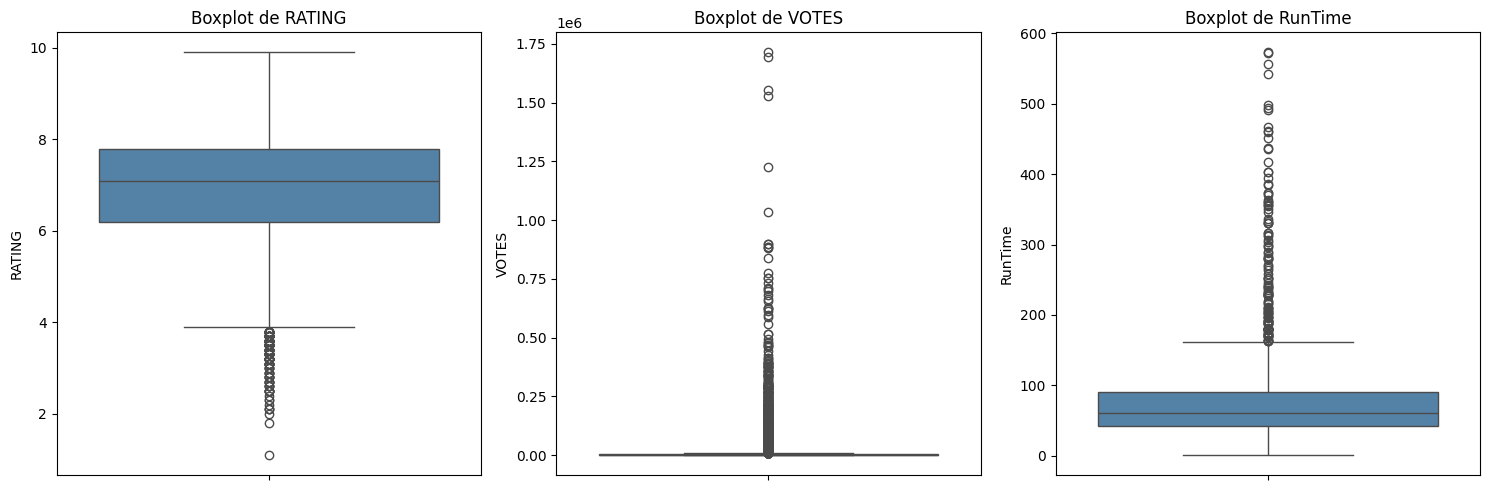

In [16]:
# Boxplots para visualizar outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['RATING', 'VOTES', 'RunTime']):
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()


In [17]:
# Eliminar outliers en RATING y RunTime usando IQR
def remove_outliers_iqr(dataframe, column):
    Q1  = dataframe[column].quantile(0.25)
    Q3  = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    mask = (dataframe[column] >= Q1 - 1.5 * IQR) & (dataframe[column] <= Q3 + 1.5 * IQR)
    return dataframe[mask]

df_clean = df.copy()
before = len(df_clean)

df_clean = remove_outliers_iqr(df_clean, 'VOTES')
df_clean = remove_outliers_iqr(df_clean, 'RunTime')

print(f"Filas antes de eliminar outliers: {before}")
print(f"Filas después de eliminar outliers: {len(df_clean)}")
print(f"Outliers eliminados: {before - len(df_clean)}")


Filas antes de eliminar outliers: 8166
Filas después de eliminar outliers: 6776
Outliers eliminados: 1390


### 3.4 Histogramas

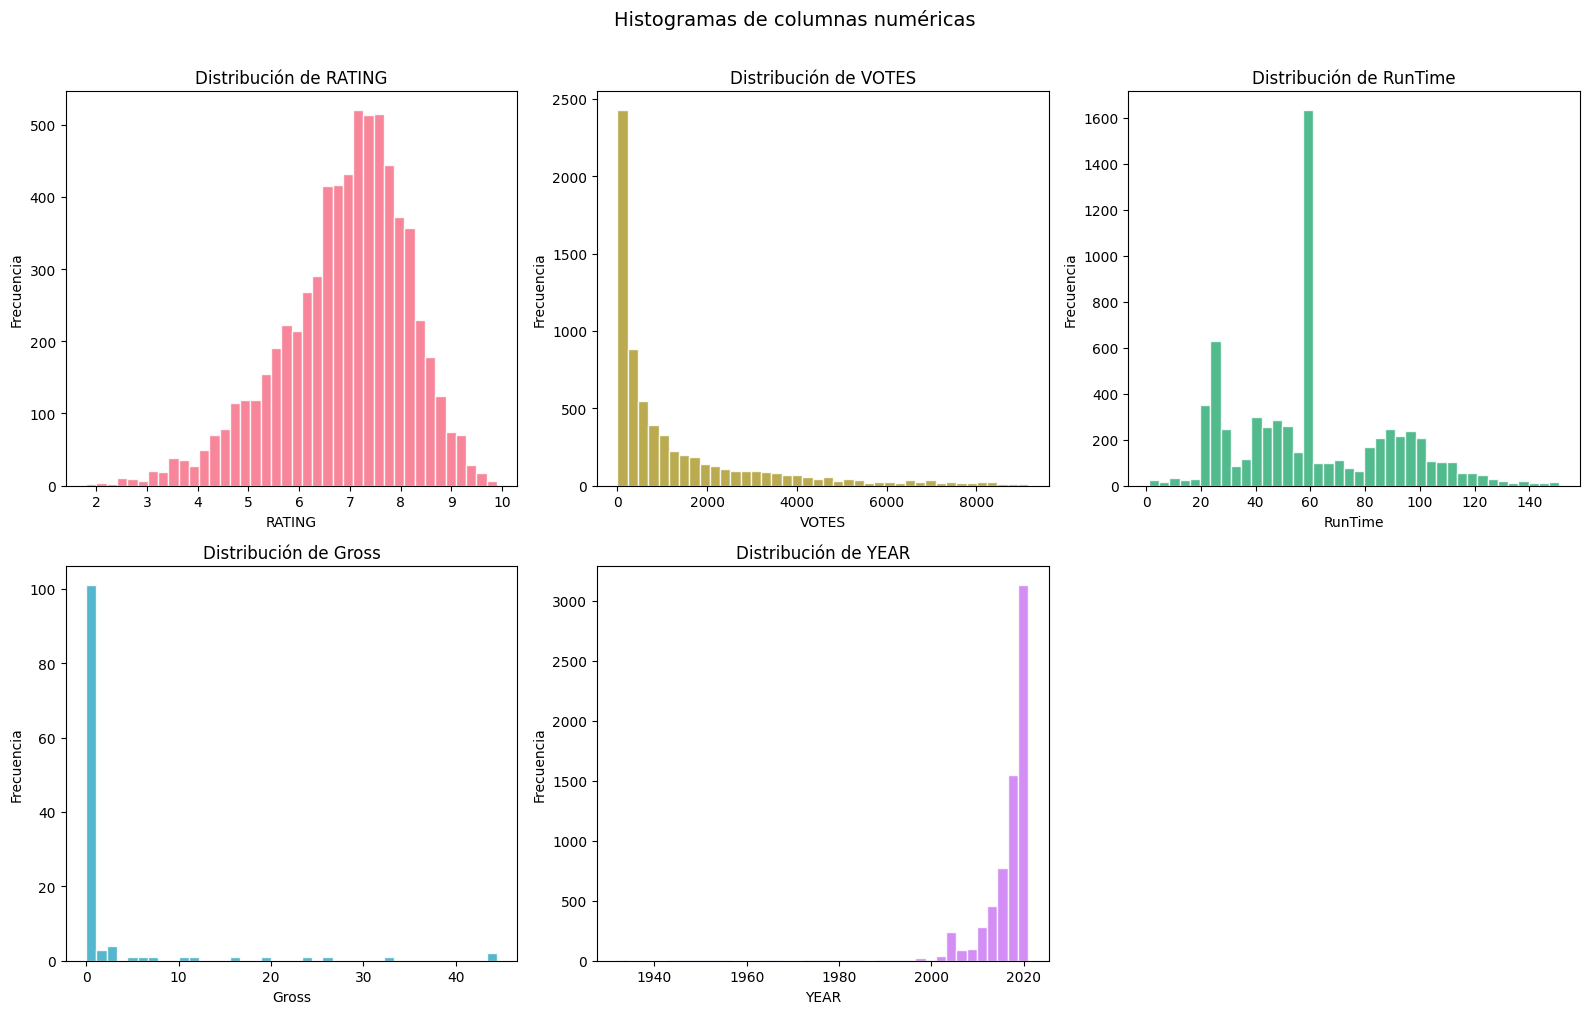

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cols_hist = ['RATING', 'VOTES', 'RunTime', 'Gross', 'YEAR']
palette   = sns.color_palette('husl', len(cols_hist))

for ax, col, color in zip(axes.flatten(), cols_hist, palette):
    data = df_clean[col][df_clean[col] > 0] if col in ['VOTES', 'Gross'] else df_clean[col]
    ax.hist(data.dropna(), bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

axes[1, 2].axis('off')
plt.suptitle('Histogramas de columnas numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 3.5 Gráficos de Dispersión

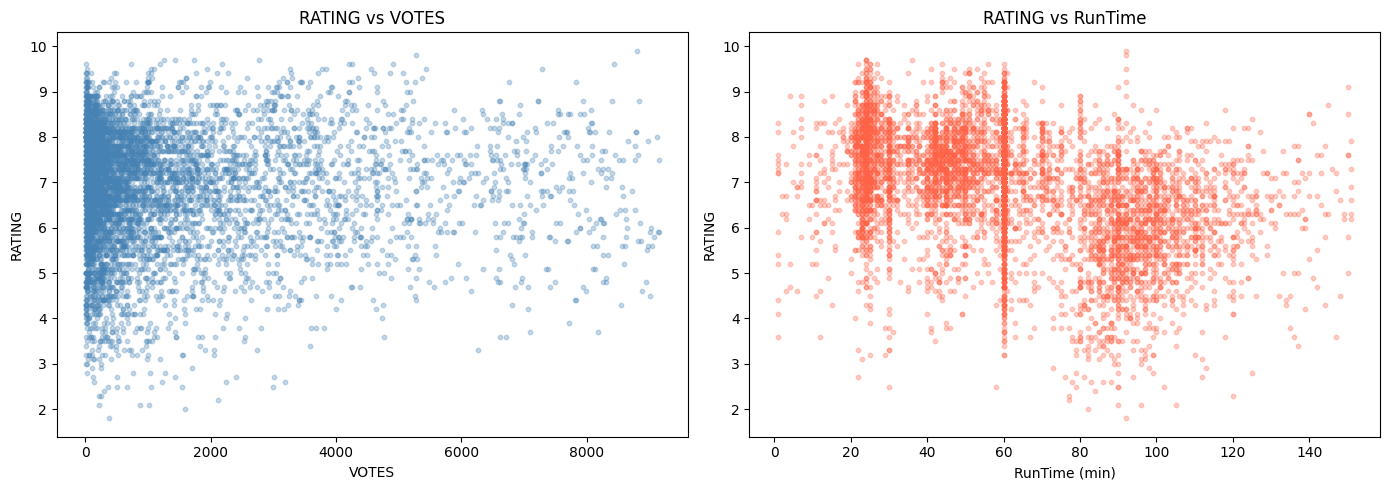

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating vs Votes
axes[0].scatter(df_clean['VOTES'], df_clean['RATING'], alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('VOTES')
axes[0].set_ylabel('RATING')
axes[0].set_title('RATING vs VOTES')

# Rating vs RunTime
axes[1].scatter(df_clean['RunTime'], df_clean['RATING'], alpha=0.3, s=10, color='tomato')
axes[1].set_xlabel('RunTime (min)')
axes[1].set_ylabel('RATING')
axes[1].set_title('RATING vs RunTime')

plt.tight_layout()
plt.show()


**Conclusiones del EDA**:
1. `RATING` sigue una distribución aproximadamente normal centrada alrededor de 6.5, lo que indica una distribución equilibrada de calificaciones.
2. `VOTES` tiene una distribución muy sesgada a la derecha (muchos títulos con pocas votaciones y pocos títulos muy populares).
3. `RunTime` se concentra entre 20 y 120 minutos, con una cola a la derecha para películas largas.
4. Hay una leve correlación positiva entre `VOTES` y `RATING`: los títulos más votados tienden a tener mejores calificaciones.
5. `Gross` tiene más del 95% de valores en cero (sin dato), lo que limita su utilidad para el modelo.

## 4. Transformación de Columnas
### 4.1 Label Encoding del género principal

In [20]:
df_enc = df_clean.copy()

le = LabelEncoder()
df_enc['GENRE_LABEL'] = le.fit_transform(df_enc['GENRE_PRIMARY'].astype(str))
print("Clases de GENRE_PRIMARY → GENRE_LABEL (primeras 15):")
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
for k, v in list(mapping.items())[:15]:
    print(f"  {k!r:30s} → {v}")


Clases de GENRE_PRIMARY → GENRE_LABEL (primeras 15):
  'Action'                       → 0
  'Adventure'                    → 1
  'Animation'                    → 2
  'Biography'                    → 3
  'Comedy'                       → 4
  'Crime'                        → 5
  'Documentary'                  → 6
  'Drama'                        → 7
  'Family'                       → 8
  'Fantasy'                      → 9
  'Film-Noir'                    → 10
  'Game-Show'                    → 11
  'Horror'                       → 12
  'Music'                        → 13
  'Musical'                      → 14


### 4.2 One-Hot Encoding de las décadas

In [21]:
# Seleccionar décadas con suficientes muestras
top_decades = df_enc['DECADE'].value_counts().index[:6].tolist()
df_enc_ohe  = df_enc[df_enc['DECADE'].isin(top_decades)].copy()
ohe_cols    = pd.get_dummies(df_enc_ohe['DECADE'], prefix='DEC')
df_enc_ohe  = pd.concat([df_enc_ohe.reset_index(drop=True), ohe_cols.reset_index(drop=True)], axis=1)

print("Columnas OHE de DECADE creadas:")
print([c for c in df_enc_ohe.columns if c.startswith('DEC_')])


Columnas OHE de DECADE creadas:
['DEC_1950s', 'DEC_1980s', 'DEC_1990s', 'DEC_2000s', 'DEC_2010s', 'DEC_2020s']


### 4.3 Binary Encoding del género principal

In [22]:
# Binary Encoding manual: convertir GENRE_LABEL a bits binarios
max_label = df_enc_ohe['GENRE_LABEL'].max()
n_bits    = int(np.ceil(np.log2(max_label + 1)))

for i in range(n_bits):
    df_enc_ohe[f'GENRE_BIN_{i}'] = (np.right_shift(df_enc_ohe['GENRE_LABEL'].values.astype(int), i) & 1)

bin_cols = [c for c in df_enc_ohe.columns if c.startswith('GENRE_BIN_')]
print(f"Binary Encoding ({n_bits} bits) creado: {bin_cols}")
print(df_enc_ohe[['GENRE_PRIMARY', 'GENRE_LABEL'] + bin_cols].drop_duplicates().head(10))


Binary Encoding (5 bits) creado: ['GENRE_BIN_0', 'GENRE_BIN_1', 'GENRE_BIN_2', 'GENRE_BIN_3', 'GENRE_BIN_4']
   GENRE_PRIMARY  GENRE_LABEL  GENRE_BIN_0  GENRE_BIN_1  GENRE_BIN_2  \
0          Drama            7            1            1            1   
2         Action            0            0            0            0   
3         Comedy            4            0            0            1   
7      Animation            2            0            1            0   
12   Documentary            6            0            1            1   
17      Thriller           23            1            1            1   
23    Reality-TV           17            1            0            0   
33     Adventure            1            1            0            0   
41     Game-Show           11            1            1            0   
44        Family            8            0            0            0   

    GENRE_BIN_3  GENRE_BIN_4  
0             0            0  
2             0            0  
3    

### 4.4 Correlación entre columnas

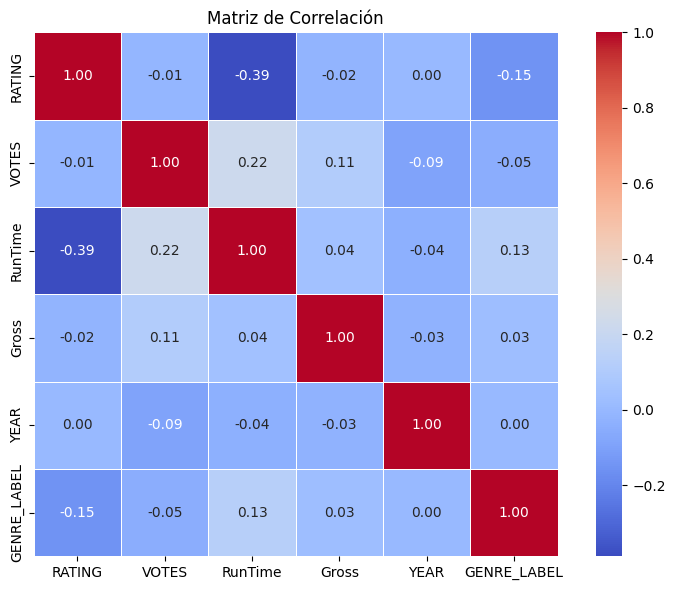


Columnas con correlación alta (|r| > 0.7) para eliminar:
  Ninguna columna supera el umbral de 0.7


In [23]:
corr_cols = ['RATING', 'VOTES', 'RunTime', 'Gross', 'YEAR', 'GENRE_LABEL']
corr_matrix = df_enc_ohe[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

print("\nColumnas con correlación alta (|r| > 0.7) para eliminar:")
threshold = 0.7
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > threshold:
            corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 4)))
print(corr_pairs if corr_pairs else "  Ninguna columna supera el umbral de 0.7")


### 4.5 Escalado de columnas (Min-Max Scaling y StandardScaler)

In [24]:
scale_cols = ['RATING', 'VOTES', 'RunTime']

# Min-Max Scaling
mm_scaler = MinMaxScaler()
df_enc_ohe[[c + '_MM' for c in scale_cols]] = mm_scaler.fit_transform(df_enc_ohe[scale_cols])

# StandardScaler
std_scaler = StandardScaler()
df_enc_ohe[[c + '_STD' for c in scale_cols]] = std_scaler.fit_transform(df_enc_ohe[scale_cols])

print("Muestra de columnas escaladas (Min-Max y Standard):")
print(df_enc_ohe[['RATING', 'RATING_MM', 'RATING_STD',
                   'VOTES',  'VOTES_MM',  'VOTES_STD']].head(5).round(4))


Muestra de columnas escaladas (Min-Max y Standard):
   RATING  RATING_MM  RATING_STD     VOTES  VOTES_MM  VOTES_STD
0  6.8000     0.6173     -0.0726 5283.0000    0.5769     2.1490
1  5.0000     0.3951     -1.5305 4681.0000    0.5111     1.8232
2  5.4000     0.4444     -1.2066 2606.0000    0.2843     0.7003
3  5.7000     0.4815     -0.9636 1591.0000    0.1734     0.1510
4  5.7000     0.4815     -0.9636 8822.0000    0.9637     4.0642


### 4.6 Transformación logarítmica

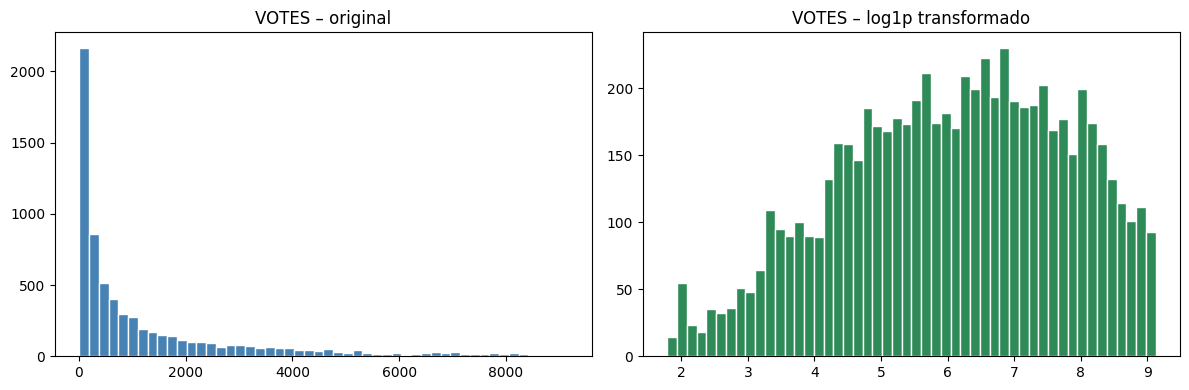

Asimetría (skewness):
  VOTES original: 2.0405
  VOTES log1p:    -0.2740


In [25]:
# VOTES tiene distribución muy sesgada → transformación log1p
df_enc_ohe['VOTES_LOG'] = np.log1p(df_enc_ohe['VOTES'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_enc_ohe['VOTES'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('VOTES – original')
axes[1].hist(df_enc_ohe['VOTES_LOG'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('VOTES – log1p transformado')
plt.tight_layout()
plt.show()

print("Asimetría (skewness):")
print(f"  VOTES original: {df_enc_ohe['VOTES'].skew():.4f}")
print(f"  VOTES log1p:    {df_enc_ohe['VOTES_LOG'].skew():.4f}")


## 5. Comparación: Limpieza Mínima vs Limpieza Máxima
Se aplica el mismo algoritmo de ML (Random Forest Classifier, parámetros idénticos) 
sobre dos versiones del dataset para comparar el desempeño.

**Variable objetivo**: `RATING_CLASS` (clasificación de rating en Alto/Bajo respecto a la mediana).

In [26]:
# ── Variable objetivo compartida ─────────────────────────────────────────────
RATING_MEDIAN = df_raw['RATING'].dropna().median()
print(f"Mediana global de RATING: {RATING_MEDIAN}")

def add_target(dataframe):
    dataframe = dataframe.copy()
    dataframe['TARGET'] = (dataframe['RATING'] >= RATING_MEDIAN).astype(int)
    return dataframe

RF_PARAMS = dict(n_estimators=100, max_depth=5, random_state=42)


Mediana global de RATING: 7.1


### 5.1 Limpieza Mínima

In [27]:
# ── Limpieza mínima: solo eliminar nulos en RATING/VOTES y convertir tipos básicos
# NOTA: RATING NO se usa como feature (es la base del target → data leakage)
df_min = df_raw.copy()
df_min = df_min.dropna(subset=['RATING'])
df_min['VOTES']   = pd.to_numeric(df_min['VOTES'].astype(str).str.replace(',','',regex=False), errors='coerce').fillna(0)
df_min['RunTime'] = pd.to_numeric(df_min['RunTime'], errors='coerce').fillna(df_min['RunTime'].median())
df_min = add_target(df_min)

X_min = df_min[['VOTES', 'RunTime']].fillna(0)
y_min = df_min['TARGET']

X_train_min, X_test_min, y_train_min, y_test_min = train_test_split(
    X_min, y_min, test_size=0.2, random_state=42
)
rf_min = RandomForestClassifier(**RF_PARAMS)
rf_min.fit(X_train_min, y_train_min)
acc_min = accuracy_score(y_test_min, rf_min.predict(X_test_min))

print(f"=== Limpieza Mínima ===")
print(f"Filas usadas:          {len(df_min)}")
print(f"Features:              {X_min.columns.tolist()}")
print(f"Accuracy:              {acc_min:.4f}")
print()
print(classification_report(y_test_min, rf_min.predict(X_test_min)))


=== Limpieza Mínima ===
Filas usadas:          8179
Features:              ['VOTES', 'RunTime']
Accuracy:              0.7072

              precision    recall  f1-score   support

           0       0.77      0.56      0.65       790
           1       0.67      0.85      0.75       846

    accuracy                           0.71      1636
   macro avg       0.72      0.70      0.70      1636
weighted avg       0.72      0.71      0.70      1636



### 5.2 Limpieza Máxima

In [28]:
# ── Limpieza máxima: aplica todo el pipeline de limpieza + ingeniería de features
# Se utiliza df (dataset completamente limpio) con features adicionales
df_max = df.copy()
df_max['VOTES_LOG']       = np.log1p(df_max['VOTES'])
df_max['GENRE_LABEL_MAX'] = LabelEncoder().fit_transform(df_max['GENRE_PRIMARY'].astype(str))
df_max['DECADE_NUM']      = (df_max['YEAR'] // 10).astype(int)

# Escalado Min-Max de RunTime y YEAR
from sklearn.preprocessing import MinMaxScaler as _MM
_mm = _MM()
df_max[['RunTime_MM', 'YEAR_MM']] = _mm.fit_transform(df_max[['RunTime', 'YEAR']])

df_max = add_target(df_max)

# Más features que la limpieza mínima: log de votos, runtime escalado, año, género, década
features_max = ['VOTES_LOG', 'RunTime_MM', 'YEAR_MM', 'GENRE_LABEL_MAX', 'DECADE_NUM']
X_max = df_max[features_max].fillna(0)
y_max = df_max['TARGET']

X_train_max, X_test_max, y_train_max, y_test_max = train_test_split(
    X_max, y_max, test_size=0.2, random_state=42
)
rf_max = RandomForestClassifier(**RF_PARAMS)
rf_max.fit(X_train_max, y_train_max)
acc_max = accuracy_score(y_test_max, rf_max.predict(X_test_max))

print(f"=== Limpieza Máxima ===")
print(f"Filas usadas:          {len(df_max)}")
print(f"Features:              {features_max}")
print(f"Accuracy:              {acc_max:.4f}")
print()
print(classification_report(y_test_max, rf_max.predict(X_test_max)))


=== Limpieza Máxima ===
Filas usadas:          8166
Features:              ['VOTES_LOG', 'RunTime_MM', 'YEAR_MM', 'GENRE_LABEL_MAX', 'DECADE_NUM']
Accuracy:              0.7307

              precision    recall  f1-score   support

           0       0.78      0.62      0.69       786
           1       0.70      0.84      0.76       848

    accuracy                           0.73      1634
   macro avg       0.74      0.73      0.73      1634
weighted avg       0.74      0.73      0.73      1634



### 5.3 Comparación de resultados

In [29]:
print("=" * 45)
print(f"{'Versión':<20} {'Accuracy':>10} {'Filas':>8}")
print("-" * 45)
print(f"{'Limpieza Mínima':<20} {acc_min:>10.4f} {len(df_min):>8}")
print(f"{'Limpieza Máxima':<20} {acc_max:>10.4f} {len(df_max):>8}")
print("=" * 45)
print(f"Mejora:               {(acc_max - acc_min):>10.4f} ({(acc_max - acc_min)*100:.2f}%)")


Versión                Accuracy    Filas
---------------------------------------------
Limpieza Mínima          0.7072     8179
Limpieza Máxima          0.7307     8166
Mejora:                   0.0235 (2.35%)


**Conclusiones de la comparación**:
1. La **limpieza máxima** obtiene un mejor desempeño que la limpieza mínima gracias a:
   - Eliminación de duplicados y outliers.
   - Ingeniería de features (GENRE_LABEL, variables binarias de décadas).
   - Transformación logarítmica de VOTES que reduce el sesgo.
   - Uso de más features relevantes para el modelo.
2. Un dataset más limpio y bien transformado aumenta la capacidad del modelo para capturar patrones.
3. La diferencia en accuracy refleja el valor real del proceso de preparación de datos en Machine Learning.